In [13]:
#Librerias
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df = pd.read_csv('bank-additional-full.csv', sep=';')
df.head() 

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [9]:
#Diccionario de datos
data_dict = pd.DataFrame({
    'Columna': df.columns,
    'Tipo de Dato': df.dtypes.values,
    'Valores Únicos': [df[col].nunique() for col in df.columns],
    'Valores Nulos (%)': [df[col].isnull().mean() * 100 for col in df.columns],
    'Ejemplo de Valores': [df[col].unique()[:5] for col in df.columns]
})
from IPython.display import display
display(data_dict)

,Columna,Tipo de Dato,Valores Únicos,Valores Nulos (%),Ejemplo de Valores
0,age,int64,78,0.0,"[56, 57, 37, 40, 45]"
1,job,object,12,0.0,"[housemaid, services, admin., blue-collar, tec..."
2,marital,object,4,0.0,"[married, single, divorced, unknown]"
3,education,object,8,0.0,"[basic.4y, high.school, basic.6y, basic.9y, pr..."
4,default,object,3,0.0,"[no, unknown, yes]"
5,housing,object,3,0.0,"[no, yes, unknown]"
6,loan,object,3,0.0,"[no, yes, unknown]"
7,contact,object,2,0.0,"[telephone, cellular]"
8,month,object,10,0.0,"[may, jun, jul, aug, oct]"
9,day_of_week,object,5,0.0,"[mon, tue, wed, thu, fri]"


In [8]:
#Particion de datos 80% / 20%
df_encoded = df.copy()
from sklearn.preprocessing import LabelEncoder
for col in df_encoded.select_dtypes(include='object'):
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (32950, 20)
Prueba: (8238, 20)


In [14]:
#Validacion cruzada
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols)
], remainder='passthrough')  

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=10000))
])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring='accuracy')
print("K-Fold Accuracy scores:", cv_scores)
print("Promedio de accuracy (K-Fold):", np.mean(cv_scores).round(4))
print("Desviación estándar:", np.std(cv_scores).round(4))

K-Fold Accuracy scores: [0.90394537 0.91411229 0.91001517 0.90591806 0.91198786]
Promedio de accuracy (K-Fold): 0.9092
Desviación estándar: 0.0038


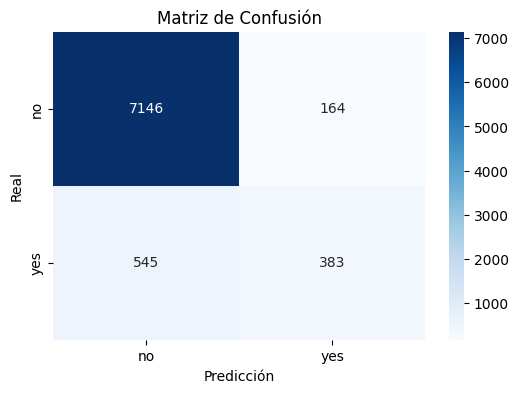

In [17]:
#Matriz de confusion 
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
labels = ['no', 'yes']

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

<span style="font-size:25px;"><b>Conclusiones</b></span>
<br>
<span style="font-size:15px;">
En el presente trabajo se ha realizado para poder evaluar la clasificacion sobre el conjunto de datos bancarios, para ello se ha implementado el proceso de validacion cruzada utilizando la tecnica de K-fold.
</span>
<br>
<span style="font-size:15px;">
El modelo de validación cruzada K-Fold tiene una precisión promedio del 90.92% y una desviación estándar de 0.38%, lo que indica una alta capacidad de generalización y baja varianza. El modelo es confiable y tiene bajo riesgo de overfitting, la matriz de confusión revela que el modelo tiene un alto rendimiento global (accuracy 90.9%), pero un desbalance en la predicción de clases, mientras que clasifica correctamente la mayoría de los casos negativos ("no"), muestra dificultades significativas para identificar correctamente los casos positivos ("yes"), con un recall del 41.3%. Esto sugiere que el modelo podría beneficiarse de técnicas de balanceo de clases o ajuste de umbral de decisión.
</span>